[Device] Using mps
Device: mps

ANALYSE DU MODE : exclusive
Saved: docs/report/images/training_exclusive.png
Saved: docs/report/images/training_exclusive.pdf


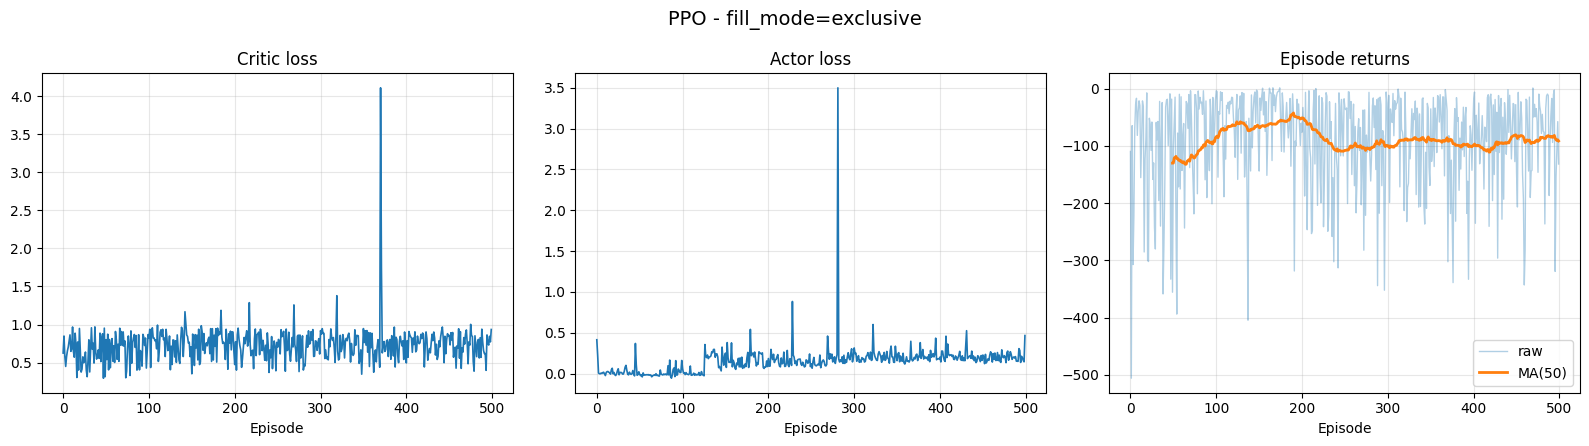

=== Rollout summary ===
steps           : 256
final inventory : 12.0000
final cash      : -1206.6533
final mtm       : 5.1454
cum reward      : -20.5236
mean delta_bid  : 0.0037
mean delta_ask  : 0.0432
mean q_bid      : 3.7142
mean q_ask      : 8.4290
Saved: docs/report/images/timeseries_exclusive.png


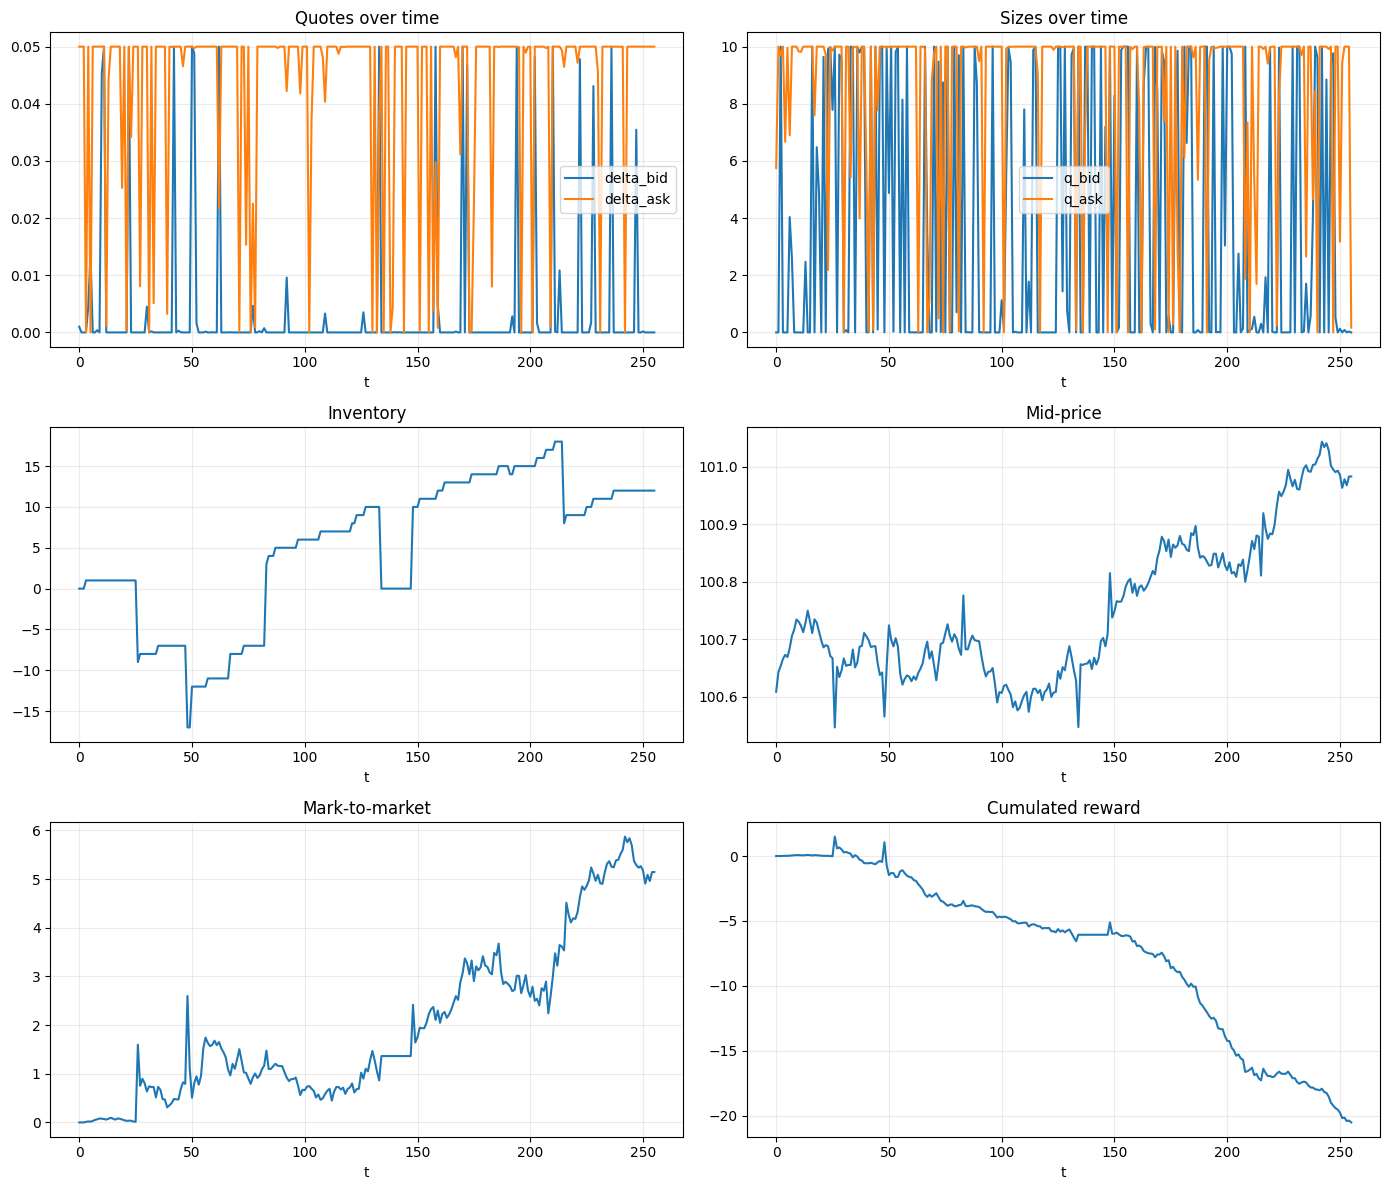

Saved: docs/report/images/state_links_exclusive.png


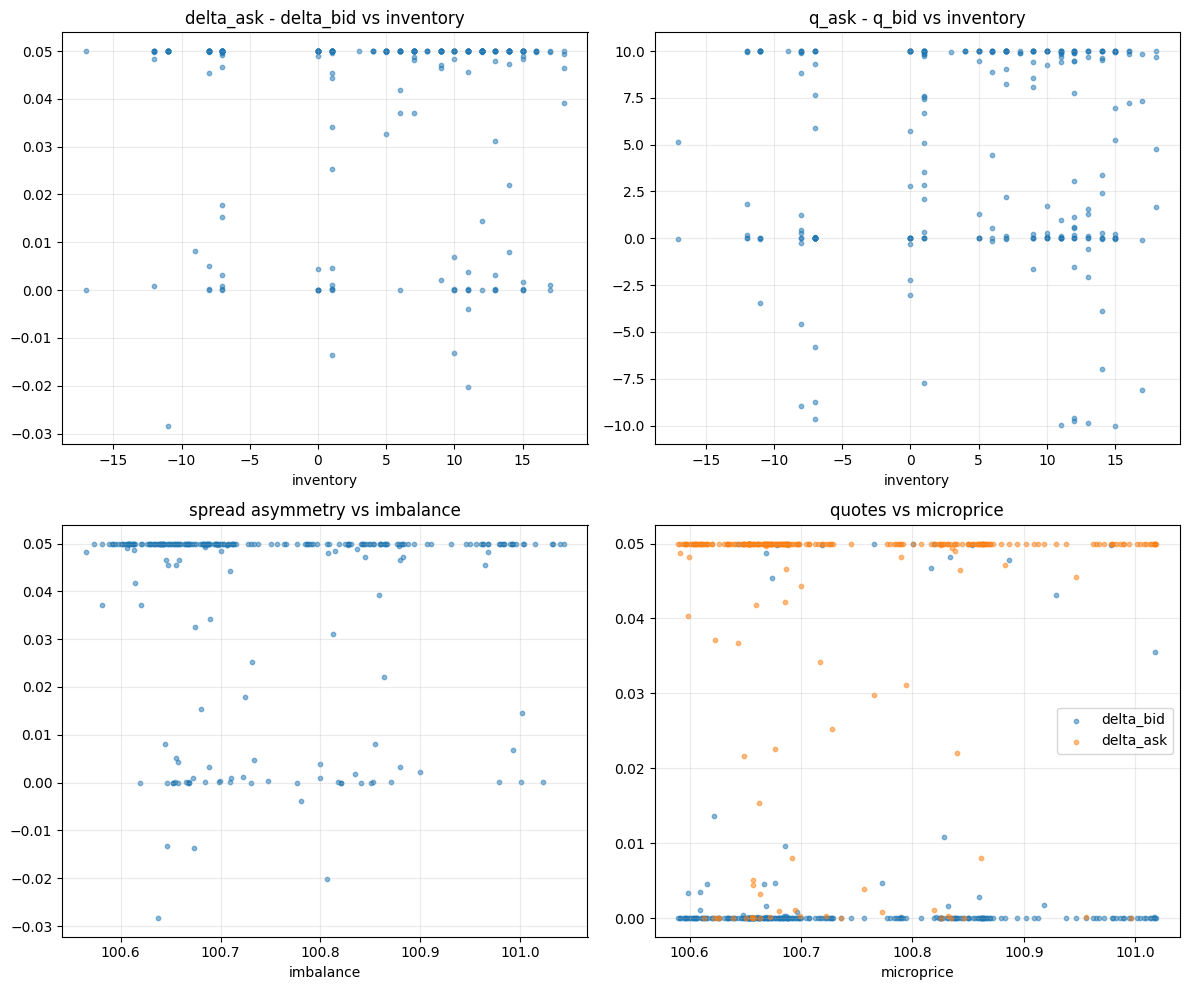


ANALYSE DU MODE : independent
Saved: docs/report/images/training_independent.png
Saved: docs/report/images/training_independent.pdf


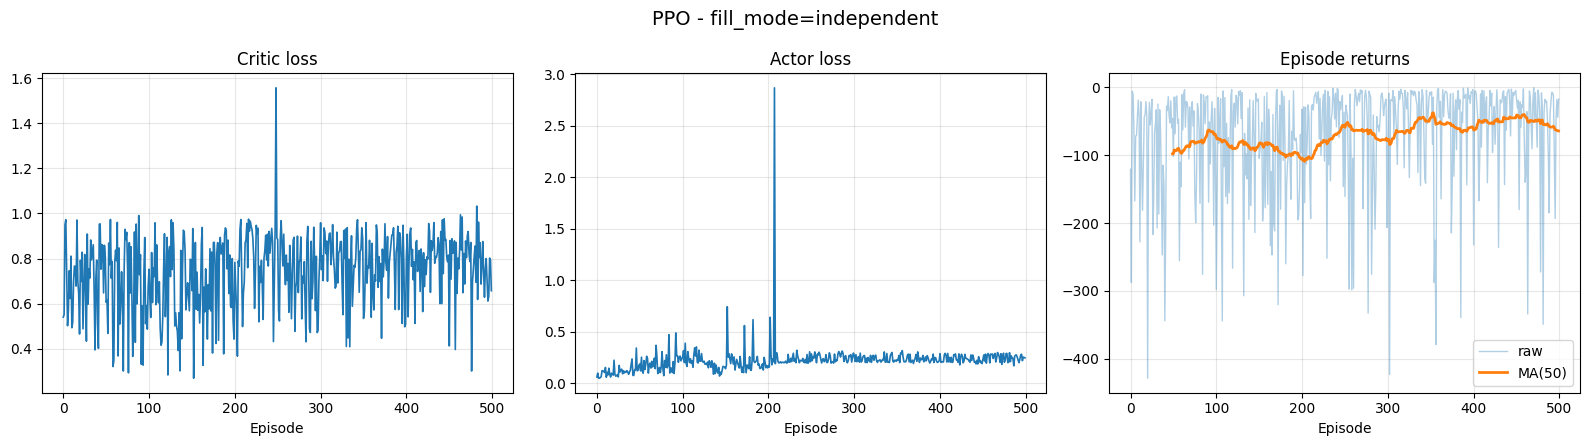

=== Rollout summary ===
steps           : 256
final inventory : -13.0000
final cash      : 1310.5575
final mtm       : -2.0944
cum reward      : -16.8224
mean delta_bid  : 0.0000
mean delta_ask  : 0.0000
mean q_bid      : 4.6234
mean q_ask      : 0.0058
Saved: docs/report/images/timeseries_independent.png


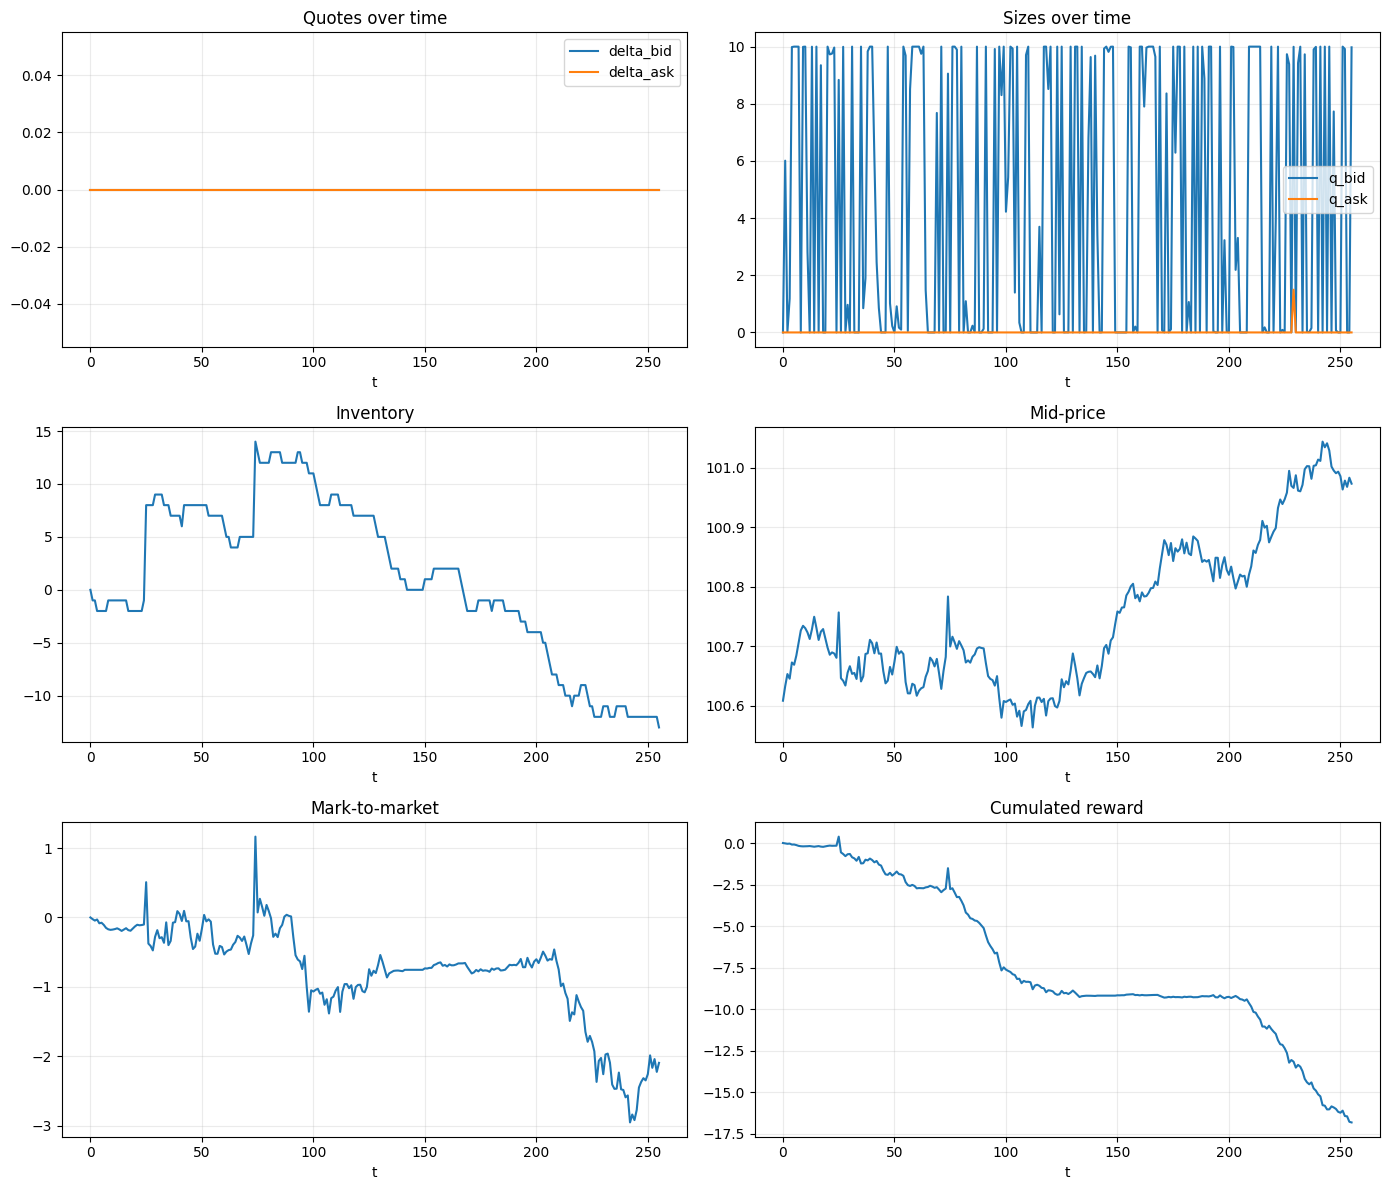

Saved: docs/report/images/state_links_independent.png


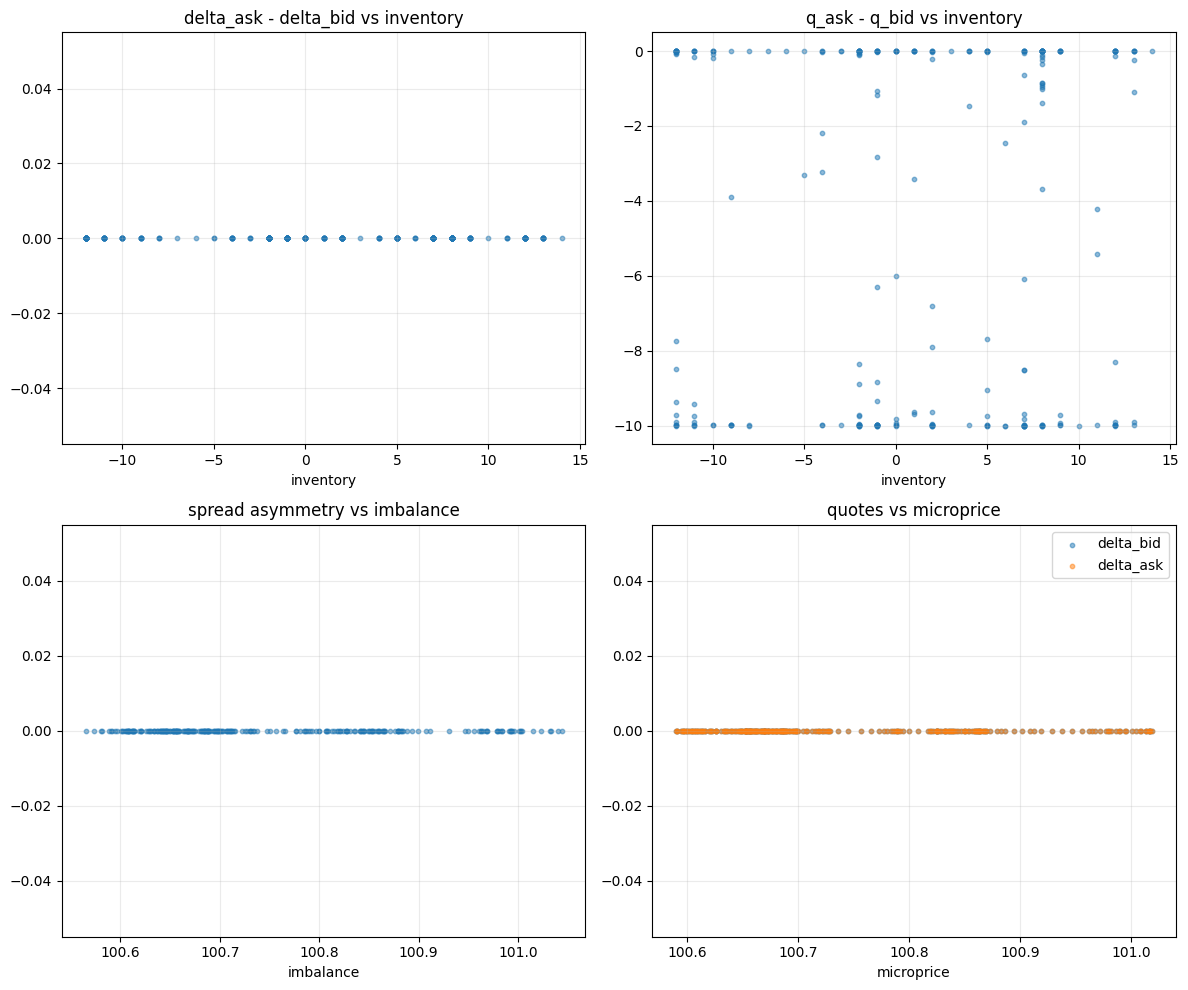


ANALYSE DU MODE : hawkes
Saved: docs/report/images/training_hawkes.png
Saved: docs/report/images/training_hawkes.pdf


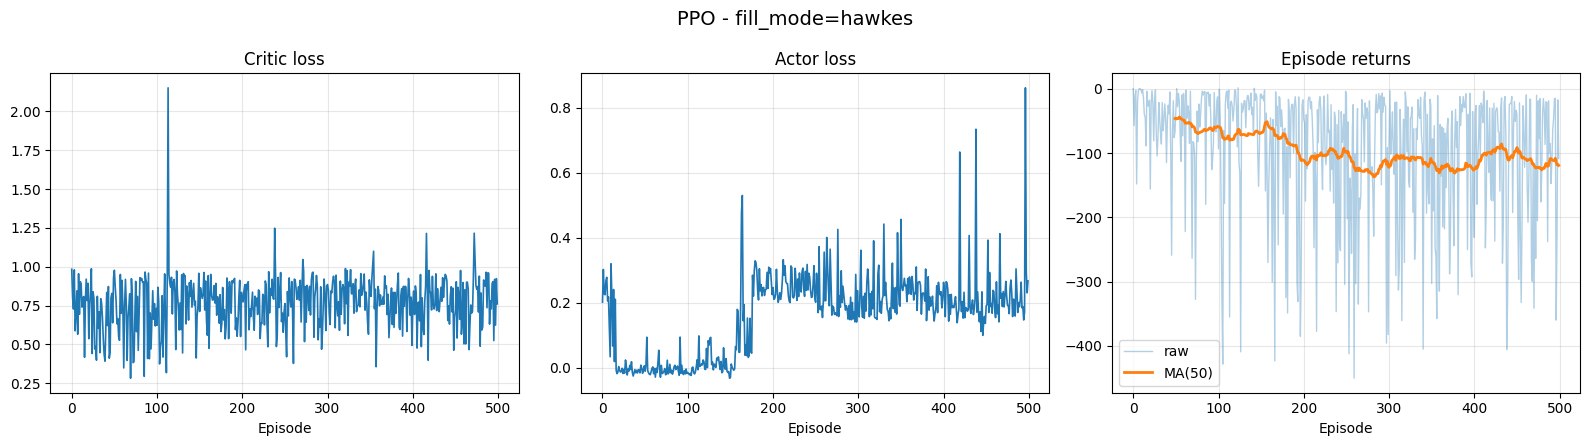

=== Rollout summary ===
steps           : 256
final inventory : -10.0000
final cash      : 1011.1142
final mtm       : 1.2819
cum reward      : -14.4491
mean delta_bid  : 0.0500
mean delta_ask  : 0.0401
mean q_bid      : 5.6497
mean q_ask      : 10.0000
Saved: docs/report/images/timeseries_hawkes.png


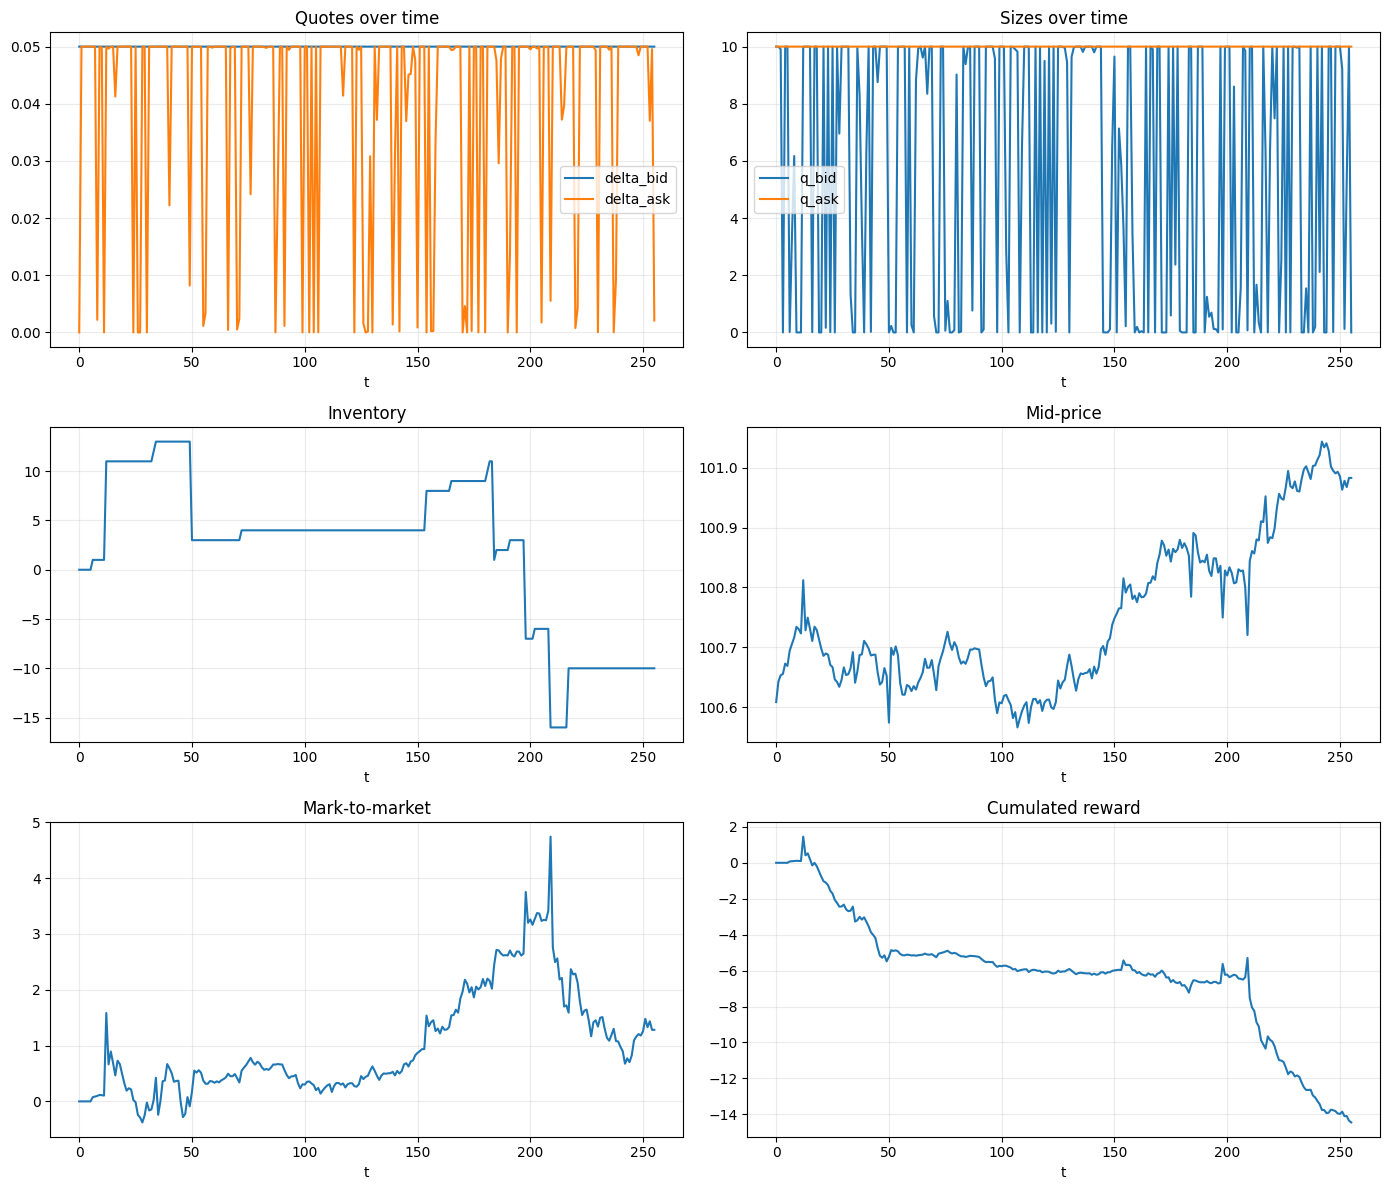

Saved: docs/report/images/state_links_hawkes.png


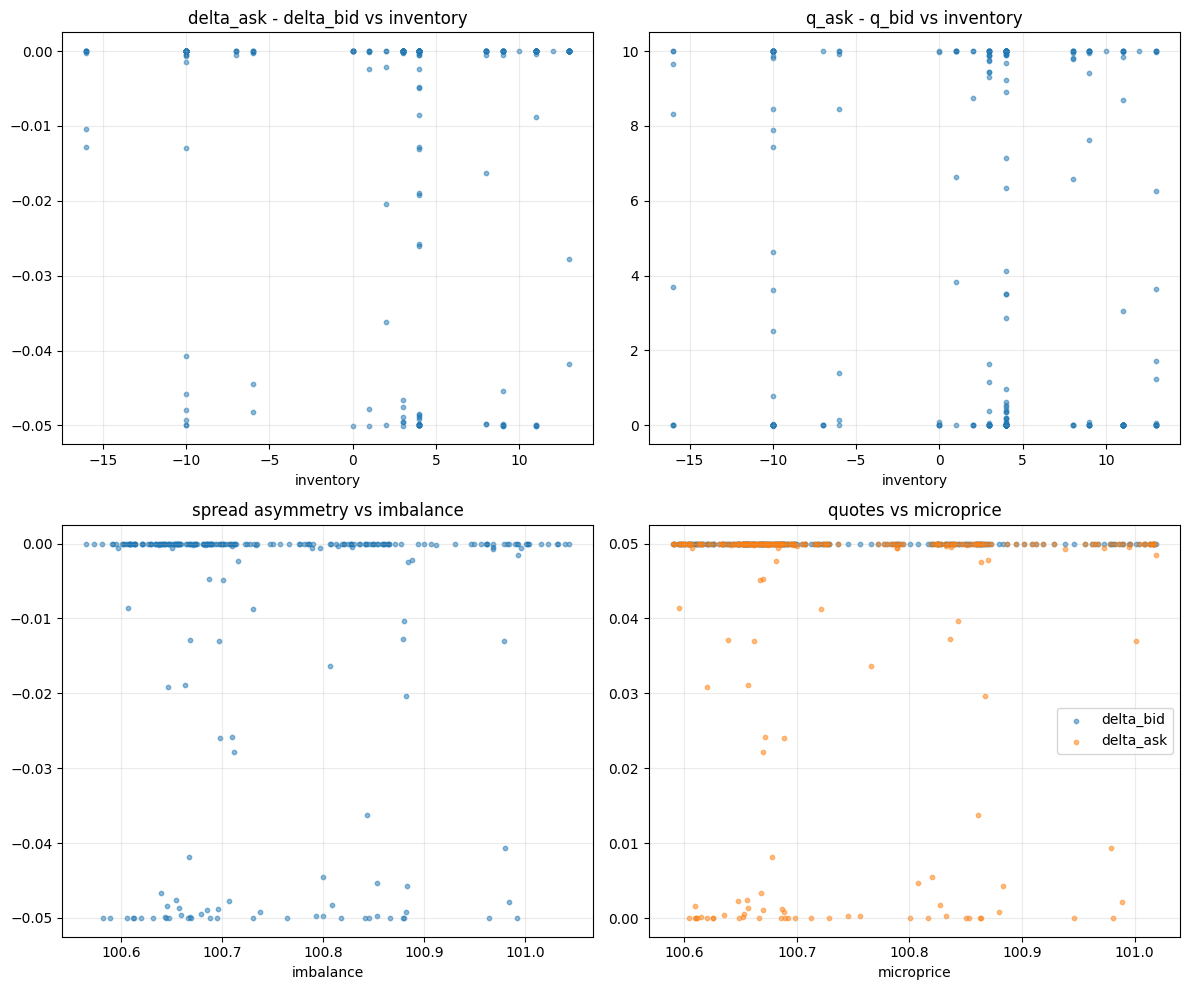

In [4]:
import os
os.chdir("/Users/franciscegoat/mm-rl")
import json
import torch
import importlib.util

from src.envs.env_toy_mm import MMSimulator
from src.ppo.networks import ActorNet
from src.utils.device import get_device

# =========================================================
# Chargement dynamique des deux fichiers si besoin
# =========================================================
def load_module_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

# Si tes fichiers sont dans src/utils, remplace simplement par des imports classiques :
from src.utils.visualisation import plot_training_results
from src.utils.policy_diagnostics import rollout_detailed, plot_policy_timeseries, plot_policy_state_links, print_rollout_summary

#vis = load_module_from_path("visualisation", "data/visualisation.py")
#diag = load_module_from_path("policy_diagnostics", "data/policy_diagnostics.py")

plot_training_results = plot_training_results
rollout_detailed = rollout_detailed
plot_policy_timeseries = plot_policy_timeseries
plot_policy_state_links = plot_policy_state_links
print_rollout_summary = print_rollout_summary

# =========================================================
# Paramètres généraux
# =========================================================
device = get_device()
print("Device:", device)

base_dir = "logs/fill_mode_comparison"
fill_modes = ["exclusive", "independent", "hawkes"]

csv_path = "data/raw/toy_lob_non_stationnary_seed42.csv"

# =========================================================
# Boucle d'analyse
# =========================================================
for fill_mode in fill_modes:
    print("\n" + "=" * 80)
    print(f"ANALYSE DU MODE : {fill_mode}")
    print("=" * 80)

    run_dir = os.path.join(base_dir, fill_mode)

    # -------------------------
    # 1. Charger config / history
    # -------------------------
    with open(os.path.join(run_dir, "config.json"), "r") as f:
        config = json.load(f)

    with open(os.path.join(run_dir, "history.json"), "r") as f:
        history = json.load(f)

    # -------------------------
    # 2. Courbes d'entraînement
    # -------------------------
    plot_training_results(
        history,
        label=f"PPO - fill_mode={fill_mode}",
        save=True,
        save_dir="docs/report/images",
        filename=f"training_{fill_mode}"
    )

    # -------------------------
    # 3. Recréer env
    # -------------------------
    env = MMSimulator(
        csv_path=csv_path,
        seed=config.get("seed", 42),
        p_fill_base=config.get("p_fill_base", 0.30),
        eta_inv=config.get("eta_inv", 1e-3),
        inv_max=config.get("inv_max", 50),
        inv_min=config.get("inv_min", -50),
        phi_as=config.get("phi_as", 0.02),
        state_mode=config.get("state_mode", "article_like"),
        dynamic_mode=config.get("dynamic_mode", "impact"),
        fill_mode=config.get("fill_mode", fill_mode),
    )

    # -------------------------
    # 4. Recréer acteur
    # -------------------------
    actor = ActorNet(
        state_dim=config["state_dim"],
        hidden_size=config["hidden_size"],
        n_layers=config["n_layers"],
        action_dim=config["action_dim"],
        delta_min=config["delta_min"],
        delta_max=config["delta_max"],
    ).to(device)

    actor.load_state_dict(
        torch.load(os.path.join(run_dir, "actor.pt"), map_location=device)
    )
    actor.eval()

    # -------------------------
    # 5. Rollout détaillé
    # -------------------------
    traj = rollout_detailed(
        env=env,
        actor=actor,
        device=device,
        max_steps=config.get("max_steps", 256),
        random_reset=True,
        deterministic=False,   # mets True pour comparer ensuite
    )

    print_rollout_summary(traj)

    # -------------------------
    # 6. Diagnostics temporels
    # -------------------------
    plot_policy_timeseries(
        traj,
        save=True,
        save_dir="docs/report/images",
        prefix=f"timeseries_{fill_mode}"
    )

    # -------------------------
    # 7. Diagnostics action/état
    # -------------------------
    # Adapte les indices si ton ordre réel d'état diffère
    plot_policy_state_links(
        traj,
        env,
        inventory_index=-1,
        imbalance_index=2,
        microprice_index=3,
        save=True,
        save_dir="docs/report/images",
        prefix=f"state_links_{fill_mode}"
    )